<a href="https://colab.research.google.com/github/YeZhou-1/ANN-homework/blob/main/HW3_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attempt to forecast the price of MSFT by analyzing the prices of multiple stocks, including MSFT, over several consecutive days leading up to the target day.



In [66]:
import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

In [67]:
def get_price(tick, start='2020-01-01', end=None):
    return yf.Ticker(tick).history(start=start, end=end)['Close']

def get_prices(tickers, start='2020-01-01', end=None):
    df = pd.DataFrame()
    for s in tickers:
        df[s] = get_price(s, start=start, end=end)
    return df

In [68]:
feature_stocks = [
    'tsla', 'meta', 'nvda', 'amzn', 'nflx',
    'gbtc', 'gdx', 'intc', 'dal', 'c',
    'goog', 'aapl', 'ibm', 'hp', 'orcl',
    'sap', 'crm', 'hubs', 'twlo'
]

predict_stock = 'msft'
start_date = '2020-01-01'

allX = get_prices(feature_stocks, start=start_date)
ally = get_prices([predict_stock], start=start_date)

In [69]:
df = allX.copy()
df[predict_stock] = ally[predict_stock]
df = df.dropna()

X_raw = df[feature_stocks].to_numpy().astype(np.float32)
Y_raw = df[predict_stock].to_numpy().reshape(-1).astype(np.float32)

print("X shape:", X_raw.shape)
print("Y shape:", Y_raw.shape)

X shape: (1591, 19)
Y shape: (1591,)


In [70]:
np.random.seed(42)

n = len(Y_raw)
indices = np.arange(n)
np.random.shuffle(indices)

train_size = int(n * 0.7)
valid_size = int(n * 0.2)
test_size = n - train_size - valid_size

train_indices = indices[:train_size]
valid_indices = indices[train_size:train_size + valid_size]
test_indices = indices[train_size + valid_size:]

print("Train size:", len(train_indices))
print("Valid size:", len(valid_indices))
print("Test size:", len(test_indices))

Train size: 1113
Valid size: 318
Test size: 160


In [71]:
X_train_raw = X_raw[train_indices]
Y_train_raw = Y_raw[train_indices]

X_mean = X_train_raw.mean(axis=0, keepdims=True)
X_std = X_train_raw.std(axis=0, keepdims=True) + 1e-8

Y_mean = Y_train_raw.mean()
Y_std = Y_train_raw.std() + 1e-8

X_scaled = (X_raw - X_mean) / X_std
Y_scaled = (Y_raw - Y_mean) / Y_std

In [72]:
class CurrentStockDataset(Dataset):
    def __init__(self, X, Y):
        """
        X shape: num_samples x num_features
        Y shape: num_samples
        """
        self.X = X.astype(np.float32)
        self.Y = Y.reshape(-1).astype(np.float32)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, index):
        x = self.X[index, :]
        y = self.Y[index]

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )

In [73]:
dataset = CurrentStockDataset(X_scaled, Y_scaled)

train_set = Subset(dataset, train_indices)
valid_set = Subset(dataset, valid_indices)
test_set = Subset(dataset, test_indices)

batch_size = 64

train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [74]:
def evaluate_model(model, test_loader, Y_mean, Y_std):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    preds = []
    trues = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)

            pred = model(x).cpu().numpy()
            y = y.numpy()

            preds.append(pred)
            trues.append(y)

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)

    preds_real = preds * Y_std + Y_mean
    trues_real = trues * Y_std + Y_mean

    mse = np.mean((preds_real - trues_real) ** 2)
    mae = np.mean(np.abs(preds_real - trues_real))
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((preds_real - trues_real) / trues_real)) * 100

    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return preds_real, trues_real, mse, mae, rmse, mape

In [75]:
def train_model(model, train_loader, valid_loader, epochs=200, lr=1e-3, patience=20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_valid_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            pred = model(x)
            loss = criterion(pred, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for x, y in valid_loader:
                x = x.to(device)
                y = y.to(device)

                pred = model(x)
                loss = criterion(pred, y)

                valid_loss += loss.item() * x.size(0)

        valid_loss /= len(valid_loader.dataset)

        print(f"Epoch {epoch + 1:03d}, Train Loss: {train_loss:.6f}, Valid Loss: {valid_loss:.6f}")

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return model

In [76]:
class LSTMCurrentStockPredictor(nn.Module):
    def __init__(self, num_stocks, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x shape: batch_size x num_stocks
        """
        x = x.unsqueeze(-1)

        out, _ = self.lstm(x)

        last_hidden = out[:, -1, :]

        pred = self.regressor(last_hidden).squeeze(-1)

        return pred

In [77]:
num_stocks = len(feature_stocks)

lstm_model = LSTMCurrentStockPredictor(
    num_stocks=num_stocks,
    hidden_dim=128,
    num_layers=2,
    dropout=0.2
)

lstm_model = train_model(
    lstm_model,
    train_dataloader,
    valid_dataloader,
    epochs=200,
    lr=1e-3,
    patience=20
)

lstm_preds, lstm_trues, lstm_mse, lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    lstm_model,
    test_dataloader,
    Y_mean,
    Y_std
)

Epoch 001, Train Loss: 0.529886, Valid Loss: 0.128159
Epoch 002, Train Loss: 0.110165, Valid Loss: 0.086009
Epoch 003, Train Loss: 0.090518, Valid Loss: 0.066016
Epoch 004, Train Loss: 0.073280, Valid Loss: 0.061082
Epoch 005, Train Loss: 0.070656, Valid Loss: 0.056926
Epoch 006, Train Loss: 0.063601, Valid Loss: 0.044190
Epoch 007, Train Loss: 0.061181, Valid Loss: 0.043366
Epoch 008, Train Loss: 0.058776, Valid Loss: 0.045238
Epoch 009, Train Loss: 0.057676, Valid Loss: 0.038390
Epoch 010, Train Loss: 0.058088, Valid Loss: 0.042131
Epoch 011, Train Loss: 0.059919, Valid Loss: 0.043360
Epoch 012, Train Loss: 0.056366, Valid Loss: 0.031651
Epoch 013, Train Loss: 0.058643, Valid Loss: 0.036983
Epoch 014, Train Loss: 0.050117, Valid Loss: 0.030219
Epoch 015, Train Loss: 0.042518, Valid Loss: 0.023085
Epoch 016, Train Loss: 0.043032, Valid Loss: 0.025230
Epoch 017, Train Loss: 0.042261, Valid Loss: 0.025141
Epoch 018, Train Loss: 0.044408, Valid Loss: 0.022037
Epoch 019, Train Loss: 0.036

In [78]:
class AttentionCurrentStockPredictor(nn.Module):
    def __init__(self, num_stocks, d_model=128, num_heads=4, num_layers=2, dropout=0.2):
        super().__init__()

        self.value_projection = nn.Linear(1, d_model)

        self.stock_embedding = nn.Parameter(
            torch.randn(1, num_stocks, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x shape: batch_size x num_stocks
        """
        x = x.unsqueeze(-1)

        h = self.value_projection(x)

        h = h + self.stock_embedding

        h = self.encoder(h)

        pooled = h.mean(dim=1)

        pred = self.regressor(pooled).squeeze(-1)

        return pred

In [79]:
attention_model = AttentionCurrentStockPredictor(
    num_stocks=num_stocks,
    d_model=128,
    num_heads=4,
    num_layers=2,
    dropout=0.2
)

attention_model = train_model(
    attention_model,
    train_dataloader,
    valid_dataloader,
    epochs=200,
    lr=1e-3,
    patience=20
)

attention_preds, attention_trues, attention_mse, attention_mae, attention_rmse, attention_mape = evaluate_model(
    attention_model,
    test_dataloader,
    Y_mean,
    Y_std
)

/tmp/ipykernel_18686/2274802684.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001, Train Loss: 0.231136, Valid Loss: 0.106234
Epoch 002, Train Loss: 0.096917, Valid Loss: 0.074214
Epoch 003, Train Loss: 0.063557, Valid Loss: 0.029308
Epoch 004, Train Loss: 0.040141, Valid Loss: 0.021985
Epoch 005, Train Loss: 0.038597, Valid Loss: 0.014618
Epoch 006, Train Loss: 0.029666, Valid Loss: 0.016845
Epoch 007, Train Loss: 0.028442, Valid Loss: 0.023435
Epoch 008, Train Loss: 0.030127, Valid Loss: 0.016345
Epoch 009, Train Loss: 0.030215, Valid Loss: 0.023192
Epoch 010, Train Loss: 0.026987, Valid Loss: 0.014034
Epoch 011, Train Loss: 0.031583, Valid Loss: 0.016770
Epoch 012, Train Loss: 0.028253, Valid Loss: 0.009587
Epoch 013, Train Loss: 0.025040, Valid Loss: 0.011035
Epoch 014, Train Loss: 0.023829, Valid Loss: 0.009125
Epoch 015, Train Loss: 0.024886, Valid Loss: 0.016666
Epoch 016, Train Loss: 0.022338, Valid Loss: 0.008525
Epoch 017, Train Loss: 0.025261, Valid Loss: 0.011646
Epoch 018, Train Loss: 0.022496, Valid Loss: 0.011804
Epoch 019, Train Loss: 0.021

In [80]:
teacher_model = AttentionCurrentStockPredictor(
    num_stocks=num_stocks,
    d_model=128,
    num_heads=4,
    num_layers=2,
    dropout=0.2
)

teacher_model = train_model(
    teacher_model,
    train_dataloader,
    valid_dataloader,
    epochs=200,
    lr=1e-3,
    patience=20
)

teacher_preds, teacher_trues, teacher_mse, teacher_mae, teacher_rmse, teacher_mape = evaluate_model(
    teacher_model,
    test_dataloader,
    Y_mean,
    Y_std
)

/tmp/ipykernel_18686/2274802684.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001, Train Loss: 0.331115, Valid Loss: 0.106162
Epoch 002, Train Loss: 0.095876, Valid Loss: 0.043233
Epoch 003, Train Loss: 0.052549, Valid Loss: 0.021416
Epoch 004, Train Loss: 0.038976, Valid Loss: 0.018257
Epoch 005, Train Loss: 0.033335, Valid Loss: 0.019764
Epoch 006, Train Loss: 0.034816, Valid Loss: 0.019755
Epoch 007, Train Loss: 0.029903, Valid Loss: 0.014961
Epoch 008, Train Loss: 0.030002, Valid Loss: 0.015835
Epoch 009, Train Loss: 0.027405, Valid Loss: 0.015441
Epoch 010, Train Loss: 0.028444, Valid Loss: 0.014963
Epoch 011, Train Loss: 0.025720, Valid Loss: 0.016399
Epoch 012, Train Loss: 0.026807, Valid Loss: 0.014110
Epoch 013, Train Loss: 0.027974, Valid Loss: 0.016461
Epoch 014, Train Loss: 0.024394, Valid Loss: 0.013044
Epoch 015, Train Loss: 0.025519, Valid Loss: 0.011185
Epoch 016, Train Loss: 0.023962, Valid Loss: 0.010270
Epoch 017, Train Loss: 0.021918, Valid Loss: 0.008293
Epoch 018, Train Loss: 0.019794, Valid Loss: 0.006799
Epoch 019, Train Loss: 0.021

In [81]:
student_model = AttentionCurrentStockPredictor(
    num_stocks=num_stocks,
    d_model=64,
    num_heads=4,
    num_layers=2,
    dropout=0.2
)

/tmp/ipykernel_18686/2274802684.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [82]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

teacher_params = count_parameters(teacher_model)
student_params = count_parameters(student_model)

print("Teacher parameters:", teacher_params)
print("Student parameters:", student_params)
print("Student divided by teacher:", student_params / teacher_params)

Teacher parameters: 276225
Student parameters: 105665
Student divided by teacher: 0.38253235586930945


/tmp/ipykernel_18686/4167631026.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [83]:
def train_student_with_distillation(
    teacher,
    student,
    train_loader,
    valid_loader,
    epochs=200,
    lr=1e-3,
    alpha=0.7,
    patience=20
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    teacher = teacher.to(device)
    student = student.to(device)

    teacher.eval()

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)

    best_valid_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        student.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            with torch.no_grad():
                teacher_pred = teacher(x)

            student_pred = student(x)

            hard_loss = criterion(student_pred, y)
            soft_loss = criterion(student_pred, teacher_pred)

            loss = alpha * hard_loss + (1.0 - alpha) * soft_loss

            optimizer.zero_grad()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)

            optimizer.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)

        student.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for x, y in valid_loader:
                x = x.to(device)
                y = y.to(device)

                pred = student(x)
                loss = criterion(pred, y)

                valid_loss += loss.item() * x.size(0)

        valid_loss /= len(valid_loader.dataset)

        print(f"Epoch {epoch + 1:03d}, Distill Train Loss: {train_loss:.6f}, Valid Loss: {valid_loss:.6f}")

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = student.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    student.load_state_dict(best_state)

    return student

In [84]:
student_model = train_student_with_distillation(
    teacher=teacher_model,
    student=student_model,
    train_loader=train_dataloader,
    valid_loader=valid_dataloader,
    epochs=200,
    lr=1e-3,
    alpha=0.7,
    patience=20
)

student_preds, student_trues, student_mse, student_mae, student_rmse, student_mape = evaluate_model(
    student_model,
    test_dataloader,
    Y_mean,
    Y_std
)

Epoch 001, Distill Train Loss: 0.373052, Valid Loss: 0.161383
Epoch 002, Distill Train Loss: 0.137881, Valid Loss: 0.081135
Epoch 003, Distill Train Loss: 0.075978, Valid Loss: 0.060691
Epoch 004, Distill Train Loss: 0.054813, Valid Loss: 0.025693
Epoch 005, Distill Train Loss: 0.039368, Valid Loss: 0.021287
Epoch 006, Distill Train Loss: 0.039480, Valid Loss: 0.025931
Epoch 007, Distill Train Loss: 0.033041, Valid Loss: 0.017595
Epoch 008, Distill Train Loss: 0.030936, Valid Loss: 0.014931
Epoch 009, Distill Train Loss: 0.028025, Valid Loss: 0.022945
Epoch 010, Distill Train Loss: 0.027858, Valid Loss: 0.017732
Epoch 011, Distill Train Loss: 0.030640, Valid Loss: 0.014910
Epoch 012, Distill Train Loss: 0.028476, Valid Loss: 0.012257
Epoch 013, Distill Train Loss: 0.027365, Valid Loss: 0.016563
Epoch 014, Distill Train Loss: 0.026591, Valid Loss: 0.011217
Epoch 015, Distill Train Loss: 0.021423, Valid Loss: 0.009176
Epoch 016, Distill Train Loss: 0.022494, Valid Loss: 0.009713
Epoch 01

In [86]:
!pip install mamba_ssm
try:
    from mamba_ssm import Mamba
except ImportError:
    Mamba = None
    print("mamba_ssm is not installed. Mamba model will be skipped.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
mamba_ssm is not installed. Mamba model will be skipped.


In [ ]:
class MambaCurrentStockPredictor(nn.Module):
    def __init__(self, num_stocks, d_model=128, num_layers=1, dropout=0.2):
        super().__init__()

        if Mamba is None:
            raise ImportError("mamba_ssm is not installed.")

        self.value_projection = nn.Linear(1, d_model)

        self.stock_embedding = nn.Parameter(
            torch.randn(1, num_stocks, d_model)
        )

        self.mamba_layers = nn.ModuleList([
            Mamba(
                d_model=d_model,
                d_state=16,
                d_conv=4,
                expand=2
            )
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.regressor = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        """
        x shape: batch_size x num_stocks
        """
        x = x.unsqueeze(-1)

        h = self.value_projection(x)

        h = h + self.stock_embedding

        for layer in self.mamba_layers:
            h = layer(h)
            h = self.dropout(h)

        pooled = h.mean(dim=1)

        pred = self.regressor(pooled).squeeze(-1)

        return pred

In [ ]:
run_mamba = False

if Mamba is not None:
    run_mamba = True

    mamba_model = MambaCurrentStockPredictor(
        num_stocks=num_stocks,
        d_model=128,
        num_layers=1,
        dropout=0.2
    )

    mamba_model = train_model(
        mamba_model,
        train_dataloader,
        valid_dataloader,
        epochs=200,
        lr=1e-3,
        patience=20
    )

    mamba_preds, mamba_trues, mamba_mse, mamba_mae, mamba_rmse, mamba_mape = evaluate_model(
        mamba_model,
        test_dataloader,
        Y_mean,
        Y_std
    )

In [88]:
results = pd.DataFrame({
    "Model": [
        "LSTM",
        "Attention",
        "Attention Teacher",
        "Distilled Attention Student"
    ],
    "MSE": [
        lstm_mse,
        attention_mse,
        teacher_mse,
        student_mse
    ],
    "MAE": [
        lstm_mae,
        attention_mae,
        teacher_mae,
        student_mae
    ],
    "RMSE": [
        lstm_rmse,
        attention_rmse,
        teacher_rmse,
        student_rmse
    ],
    "MAPE": [
        lstm_mape,
        attention_mape,
        teacher_mape,
        student_mape
    ]
})



results

,Model,MSE,MAE,RMSE,MAPE
0,LSTM,68.762436,6.905948,8.292312,2.423496
1,Attention,33.945560,4.522780,5.826282,1.466800
2,Attention Teacher,49.537445,5.485109,7.038284,1.839904
3,Distilled Attention Student,41.638802,5.193730,6.452814,1.711195


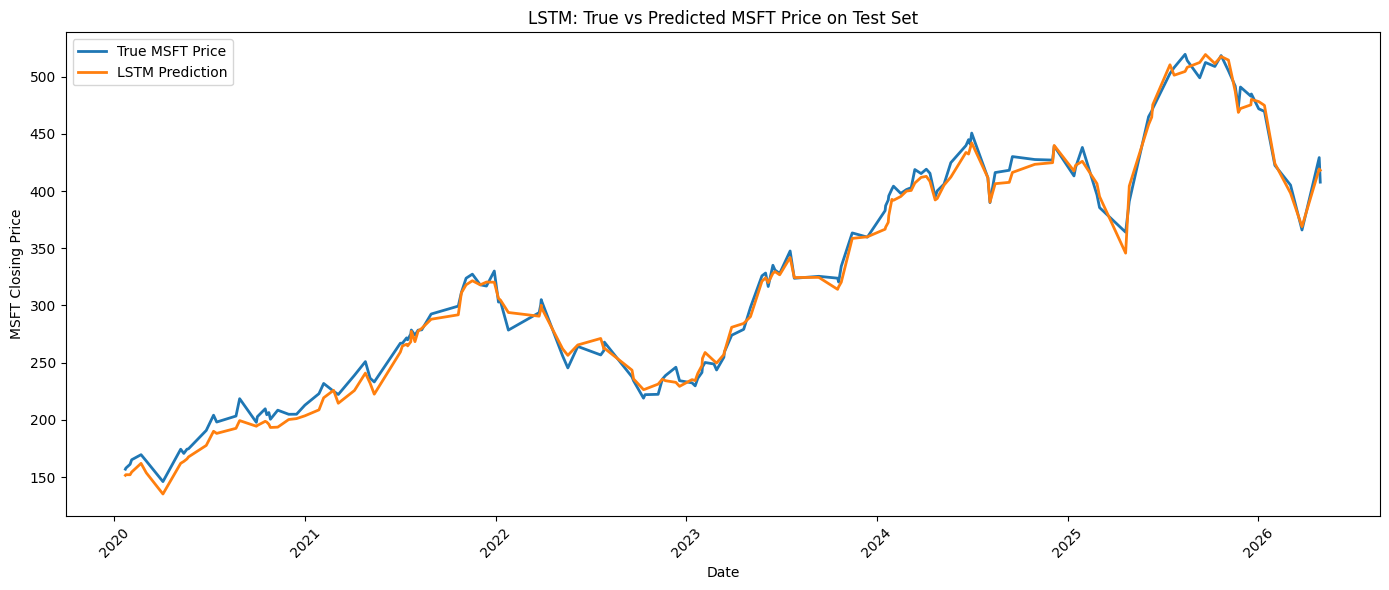

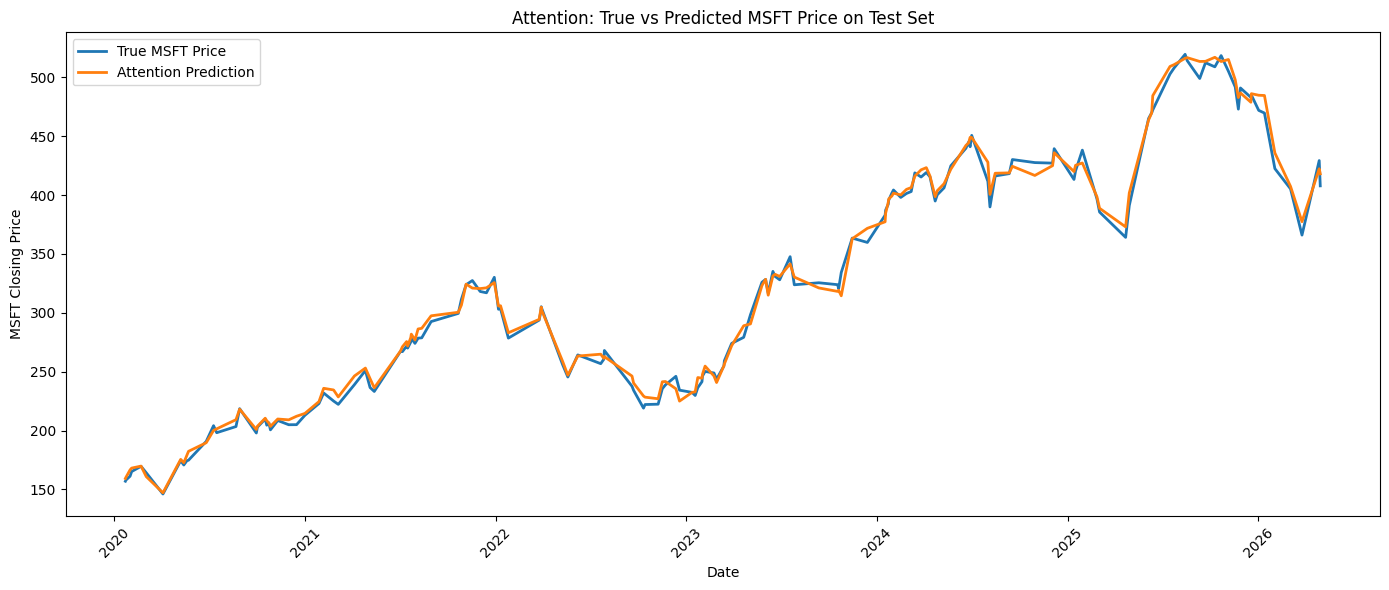

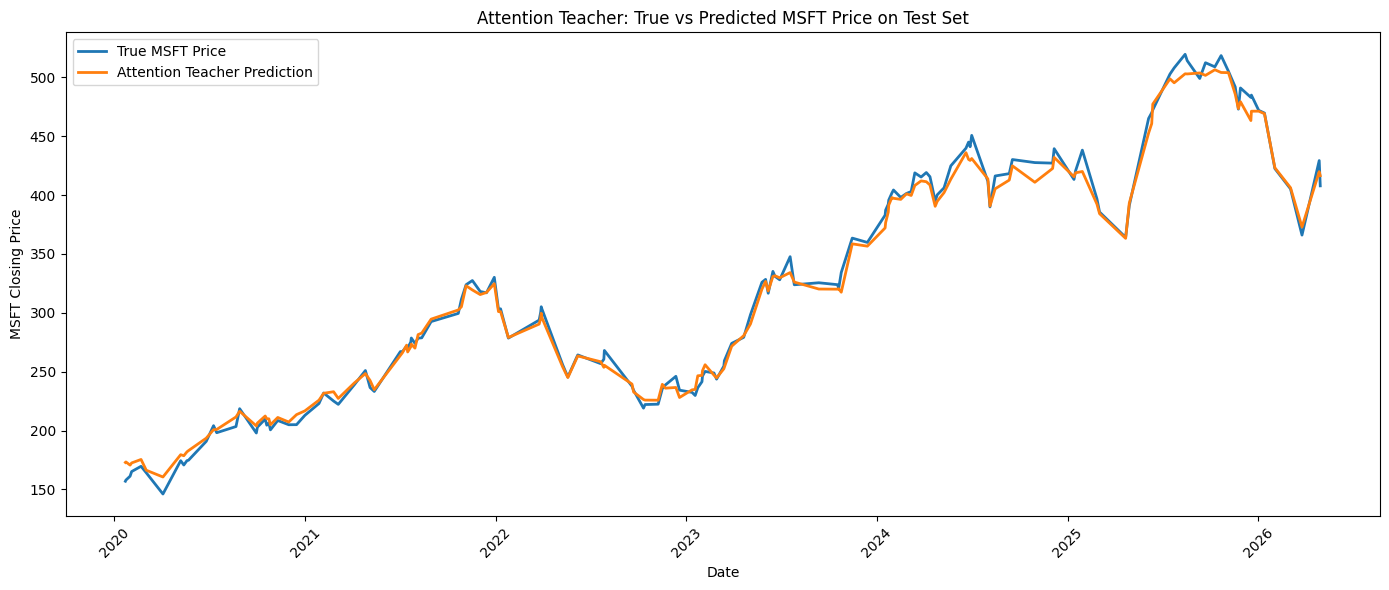

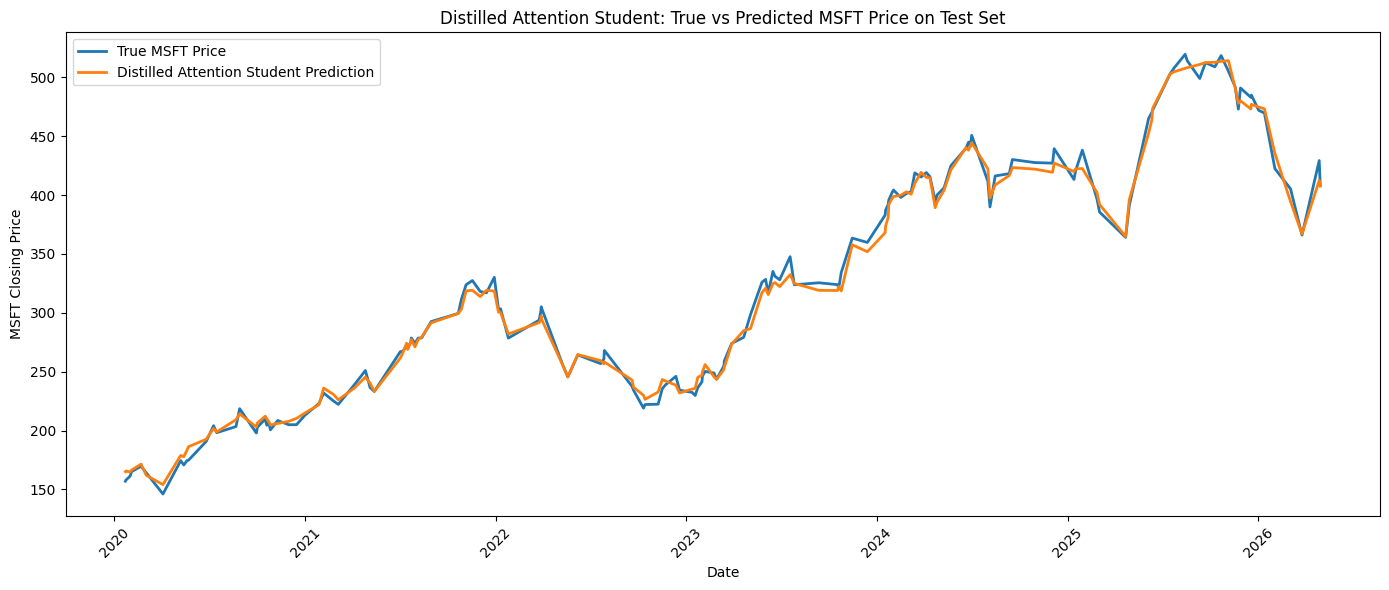

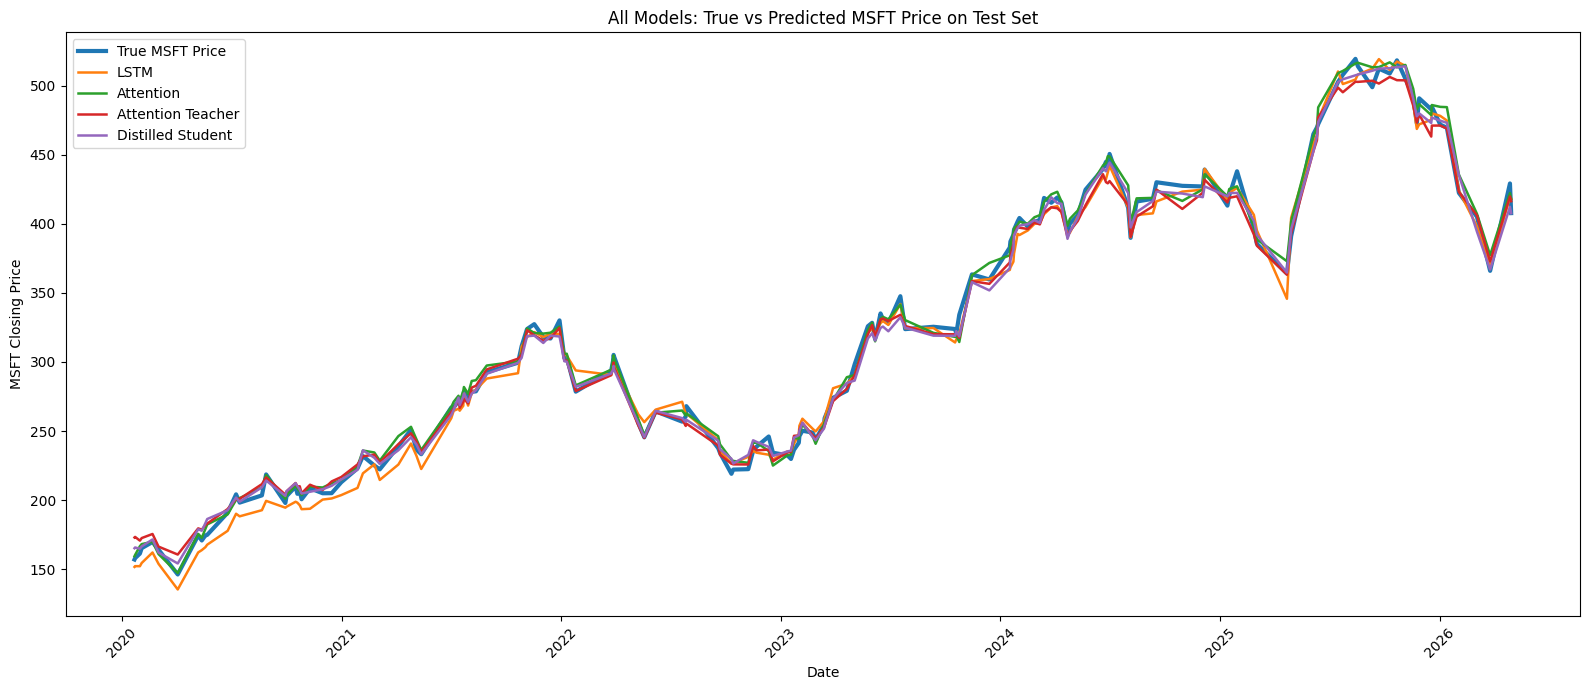

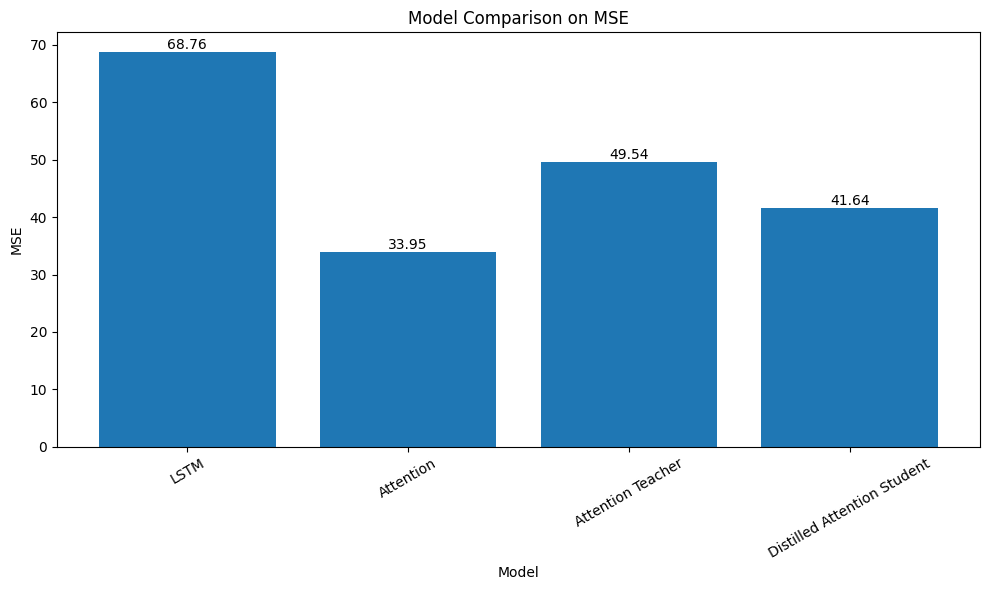

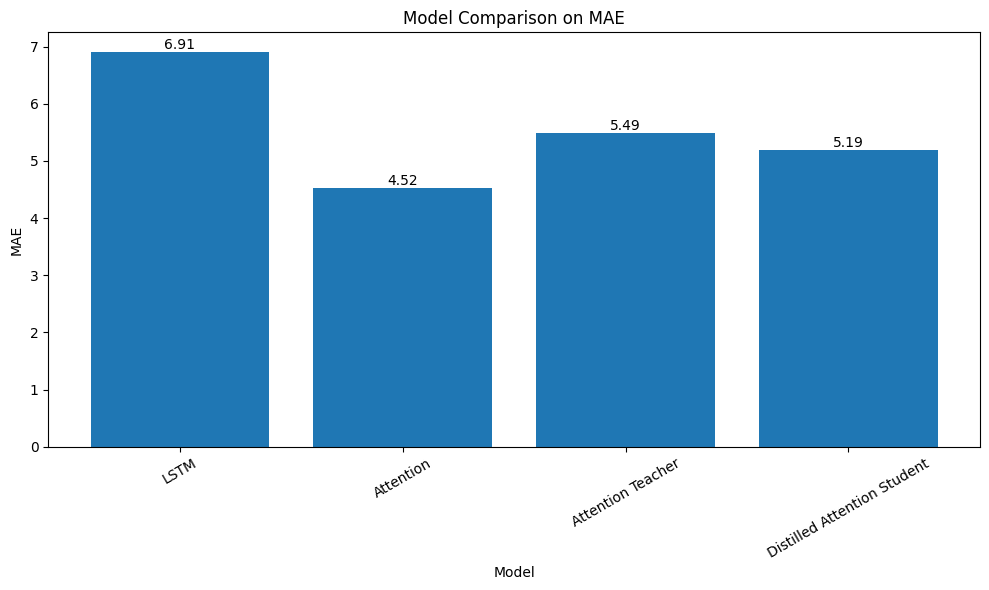

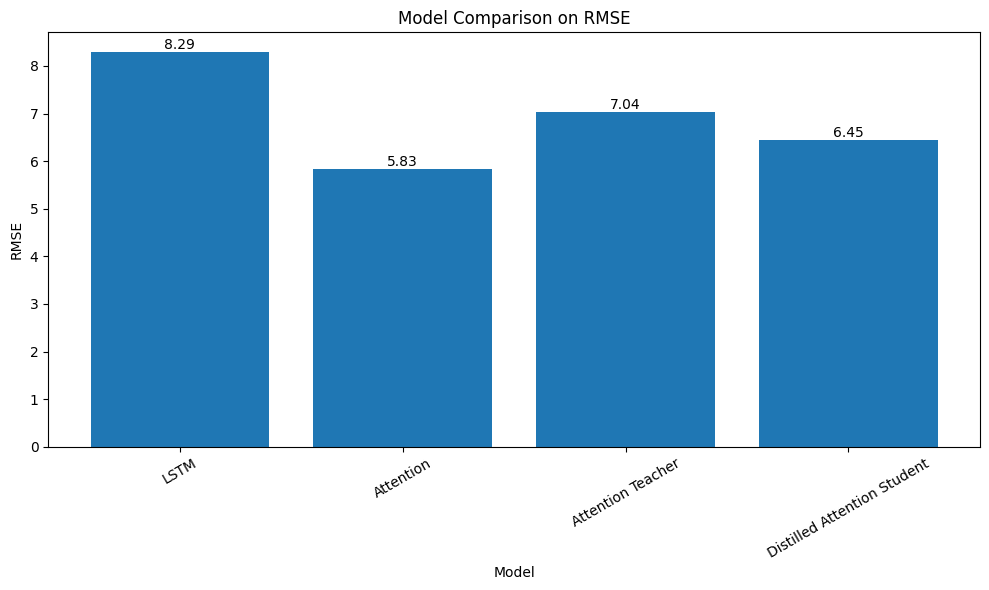

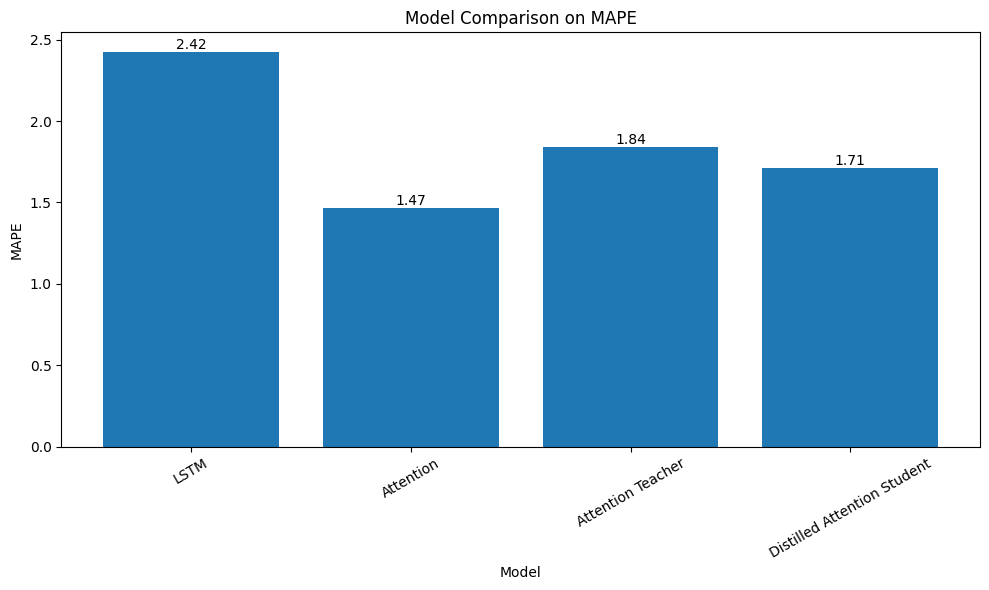

In [89]:
import matplotlib.pyplot as plt
import numpy as np

test_dates = df.index[test_indices]
sorted_order = np.argsort(test_dates)
sorted_test_dates = test_dates[sorted_order]

true_sorted = lstm_trues[sorted_order]
lstm_preds_sorted = lstm_preds[sorted_order]
attention_preds_sorted = attention_preds[sorted_order]
teacher_preds_sorted = teacher_preds[sorted_order]
student_preds_sorted = student_preds[sorted_order]



def plot_true_vs_pred(dates, true_values, pred_values, model_name):
    plt.figure(figsize=(14, 6))
    plt.plot(dates, true_values, label='True MSFT Price', linewidth=2)
    plt.plot(dates, pred_values, label=f'{model_name} Prediction', linewidth=2)
    plt.title(f'{model_name}: True vs Predicted MSFT Price on Test Set')
    plt.xlabel('Date')
    plt.ylabel('MSFT Closing Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_all_models_vs_true(dates, true_values, pred_dict):
    plt.figure(figsize=(16, 7))
    plt.plot(dates, true_values, label='True MSFT Price', linewidth=3)
    for model_name, pred_values in pred_dict.items():
        plt.plot(dates, pred_values, label=model_name, linewidth=1.8)
    plt.title('All Models: True vs Predicted MSFT Price on Test Set')
    plt.xlabel('Date')
    plt.ylabel('MSFT Closing Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_metric_bar_with_values(results_df, metric_name):
    plt.figure(figsize=(10, 6))
    bars = plt.bar(results_df['Model'], results_df[metric_name])
    plt.title(f'Model Comparison on {metric_name}')
    plt.xlabel('Model')
    plt.ylabel(metric_name)
    plt.xticks(rotation=30)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}',
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

plot_true_vs_pred(sorted_test_dates, true_sorted, lstm_preds_sorted, 'LSTM')
plot_true_vs_pred(sorted_test_dates, true_sorted, attention_preds_sorted, 'Attention')
plot_true_vs_pred(sorted_test_dates, true_sorted, teacher_preds_sorted, 'Attention Teacher')
plot_true_vs_pred(sorted_test_dates, true_sorted, student_preds_sorted, 'Distilled Attention Student')

pred_dict = {
    'LSTM': lstm_preds_sorted,
    'Attention': attention_preds_sorted,
    'Attention Teacher': teacher_preds_sorted,
    'Distilled Student': student_preds_sorted
}



plot_all_models_vs_true(sorted_test_dates, true_sorted, pred_dict)

plot_metric_bar_with_values(results, 'MSE')
plot_metric_bar_with_values(results, 'MAE')
plot_metric_bar_with_values(results, 'RMSE')
plot_metric_bar_with_values(results, 'MAPE')